# Audience Sentiment Analyzer

## Objective

To analyze textual user comments using Natural Language Processing (NLP)
and identify audience sentiment and relatability patterns.

The module uses real YouTube comments and applies text preprocessing and
machine learning to understand audience reactions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 150)

In [2]:
comments_df = pd.read_csv(
    "YoutubeCommentsDataSet.csv"
)

comments_df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 required a brand new iphone in order to use it a significant portion of apples user base wasnt able to use ...,neutral
1,here in nz 50 of retailers don’t even have contactless credit card machines like paywave which support apple pay they don’t like the high fees tha...,negative
2,i will forever acknowledge this channel with the help of your lessons and ideas explanations now its quite helpful while youll just sit at your co...,positive
3,whenever i go to a place that doesn’t take apple pay doesn’t happen too often it’s such a drag between ‘contactless covid’ habits and my getting t...,negative
4,apple pay is so convenient secure and easy to use i used it while at the korean and japanese airports no need for physical credit cards,positive


In [3]:
print("Dataset Shape:", comments_df.shape)

comments_df.info()

Dataset Shape: (18408, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  object
dtypes: object(2)
memory usage: 287.8+ KB


In [4]:
comments_df.columns.tolist()

['Comment', 'Sentiment']

In [5]:
comments_df["Sentiment"].value_counts()

Sentiment
positive    11432
neutral      4638
negative     2338
Name: count, dtype: int64

## Data Cleaning

The comment dataset is checked for missing values, duplicate records, empty
comments, and inconsistent sentiment labels before text preprocessing.

In [6]:
# Check missing values
comments_df.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

In [7]:
# Check duplicate rows
print("Duplicate rows:", comments_df.duplicated().sum())

# Check duplicate comments
print(
    "Duplicate comments:",
    comments_df["Comment"].duplicated().sum()
)

Duplicate rows: 531
Duplicate comments: 536


In [8]:
comments_df["Sentiment"].unique()

array(['neutral', 'negative', 'positive'], dtype=object)

In [9]:
comments_df["Comment_Length"] = (
    comments_df["Comment"]
    .fillna("")
    .astype(str)
    .str.len()
)

comments_df["Comment_Length"].describe()

count    18408.000000
mean       177.129726
std        250.899524
min          0.000000
25%         66.000000
50%        113.000000
75%        201.000000
max       7847.000000
Name: Comment_Length, dtype: float64

In [10]:
# Check comments that appear with more than one sentiment label

conflicting_comments = (
    comments_df.dropna(subset=["Comment"])
    .groupby("Comment")["Sentiment"]
    .nunique()
)

conflicting_comments = conflicting_comments[
    conflicting_comments > 1
]

print("Comments with conflicting sentiment labels:",
      len(conflicting_comments))

Comments with conflicting sentiment labels: 3


In [11]:
comments_df[
    comments_df["Comment"].isin(conflicting_comments.index)
].sort_values("Comment")

,Comment,Sentiment,Comment_Length
2290,get your bonus,neutral,15
2301,get your bonus,positive,15
11547,problems sempre alegrando nossos dias,positive,37
11549,problems sempre alegrando nossos dias,neutral,37
12071,want to read these tips instead of watchcheck out the blog for this video aiming for 750 on readingcheck out supertutortvcomsuperseminar for our 2...,neutral,463
12401,want to read these tips instead of watchcheck out the blog for this video aiming for 750 on readingcheck out supertutortvcomsuperseminar for our 2...,positive,463


In [12]:
# Remove comments having conflicting sentiment labels

comments_df = comments_df[
    ~comments_df["Comment"].isin(conflicting_comments.index)
].copy()

print("Shape after removing conflicting comments:",
      comments_df.shape)

Shape after removing conflicting comments: (18402, 3)


In [13]:
# Remove rows with missing comment text

comments_df = comments_df.dropna(
    subset=["Comment"]
).copy()

print("Shape after removing missing comments:",
      comments_df.shape)

Shape after removing missing comments: (18358, 3)


In [14]:
# Remove exact duplicate rows

comments_df = comments_df.drop_duplicates().copy()

print("Shape after removing duplicates:",
      comments_df.shape)

Shape after removing duplicates: (17868, 3)


In [15]:
print("Missing values:")
print(comments_df.isnull().sum())

print("\nDuplicate rows:",
      comments_df.duplicated().sum())

print("\nDuplicate comments:",
      comments_df["Comment"].duplicated().sum())

Missing values:
Comment           0
Sentiment         0
Comment_Length    0
dtype: int64

Duplicate rows: 0

Duplicate comments: 0


In [16]:
comments_df.nlargest(
    5,
    "Comment_Length"
)[
    ["Comment", "Sentiment", "Comment_Length"]
]

,Comment,Sentiment,Comment_Length
3984,timestamps this took forever v2 001 intro ——————————— 035 original nxn 040 1x1 054 lanlan 2x2 110 rubik’s 3x3 125 rubik’s 4x4 138 rubik’s 5x5 154 ...,neutral,7847
16407,description of exclusive video footage 110 panel starts with a sizzle reel narrated by stan lee marvel has always been and always will be a reflec...,neutral,6031
18276,000000 00 introduction to the video speaker ml agenda 1 core concepts 2 python based 3 scenario based questions 000307 01 how can concept of ml ca...,neutral,5597
10493,tracklist 0000 kanisan ft wishes and dreams morning moon 0223 kupla lavender 0452 amies destination unknow 0740 tenno overgrown 0954 raimu sinkin...,neutral,5586
11370,i found this very interesting and as someone with adhdi i had a lot of hyperfocused thoughts about it it brought up so many points of interest wit...,positive,5487


**Observation:**  
Some extremely long records contain timestamp lists, tracklists, or video-description
style text rather than typical comments. However, genuine long comments are also
present. Therefore, records are not removed solely on the basis of comment length
to avoid discarding valid user feedback.

## Text Preprocessing

Comment text is normalized before NLP modeling. URLs and unnecessary whitespace
are removed and text is converted to lowercase.

Stopwords are not removed at this stage because words such as "not" can carry
important sentiment information.

In [17]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

comments_df["Clean_Comment"] = comments_df["Comment"].apply(clean_text)

In [18]:
comments_df[
    ["Comment", "Clean_Comment", "Sentiment"]
].head()

,Comment,Clean_Comment,Sentiment
0,lets not forget that apple pay in 2014 required a brand new iphone in order to use it a significant portion of apples user base wasnt able to use ...,lets not forget that apple pay in 2014 required a brand new iphone in order to use it a significant portion of apples user base wasnt able to use ...,neutral
1,here in nz 50 of retailers don’t even have contactless credit card machines like paywave which support apple pay they don’t like the high fees tha...,here in nz 50 of retailers don’t even have contactless credit card machines like paywave which support apple pay they don’t like the high fees tha...,negative
2,i will forever acknowledge this channel with the help of your lessons and ideas explanations now its quite helpful while youll just sit at your co...,i will forever acknowledge this channel with the help of your lessons and ideas explanations now its quite helpful while youll just sit at your co...,positive
3,whenever i go to a place that doesn’t take apple pay doesn’t happen too often it’s such a drag between ‘contactless covid’ habits and my getting t...,whenever i go to a place that doesn’t take apple pay doesn’t happen too often it’s such a drag between ‘contactless covid’ habits and my getting t...,negative
4,apple pay is so convenient secure and easy to use i used it while at the korean and japanese airports no need for physical credit cards,apple pay is so convenient secure and easy to use i used it while at the korean and japanese airports no need for physical credit cards,positive


In [19]:
print(
    "Empty comments after preprocessing:",
    (comments_df["Clean_Comment"].str.len() == 0).sum()
)

Empty comments after preprocessing: 0


## Sentiment Classification Model

The cleaned comments are used to train a machine learning model that predicts
whether a comment is Positive, Neutral, or Negative.

In [20]:
comments_df["Sentiment"].value_counts()

Sentiment
positive    11051
neutral      4500
negative     2317
Name: count, dtype: int64

In [21]:
X = comments_df["Clean_Comment"]
y = comments_df["Sentiment"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (17868,)
y Shape: (17868,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training samples: 14294
Testing samples: 3574

Training distribution:
Sentiment
positive    8841
neutral     3600
negative    1853
Name: count, dtype: int64

Testing distribution:
Sentiment
positive    2210
neutral      900
negative     464
Name: count, dtype: int64


### TF-IDF Feature Extraction

TF-IDF converts comment text into numerical features based on the importance
of words within the comment collection.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (14294, 10000)
Testing TF-IDF Shape: (3574, 10000)


### Sentiment Classification using Logistic Regression

A Logistic Regression classifier is trained on the TF-IDF features to classify
comments as Positive, Neutral, or Negative.

Balanced class weights are used because the sentiment classes are not equally
represented in the dataset.

In [25]:
from sklearn.linear_model import LogisticRegression

sentiment_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

sentiment_model.fit(
    X_train_tfidf,
    y_train
)

print("Sentiment model trained successfully.")

Sentiment model trained successfully.


In [26]:
y_pred = sentiment_model.predict(
    X_test_tfidf
)

y_pred[:20]

array(['positive', 'neutral', 'positive', 'neutral', 'positive',
       'positive', 'neutral', 'positive', 'positive', 'positive',
       'positive', 'positive', 'negative', 'negative', 'positive',
       'negative', 'positive', 'positive', 'positive', 'neutral'],
      dtype=object)

### Model Evaluation

The model is evaluated using Accuracy, Precision, Recall, F1 Score,
and a class-wise classification report.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.727
Precision: 0.765
Recall   : 0.727
F1 Score : 0.74

Classification Report:

              precision    recall  f1-score   support

    negative       0.44      0.61      0.51       464
     neutral       0.57      0.67      0.62       900
    positive       0.91      0.78      0.84      2210

    accuracy                           0.73      3574
   macro avg       0.64      0.68      0.66      3574
weighted avg       0.76      0.73      0.74      3574



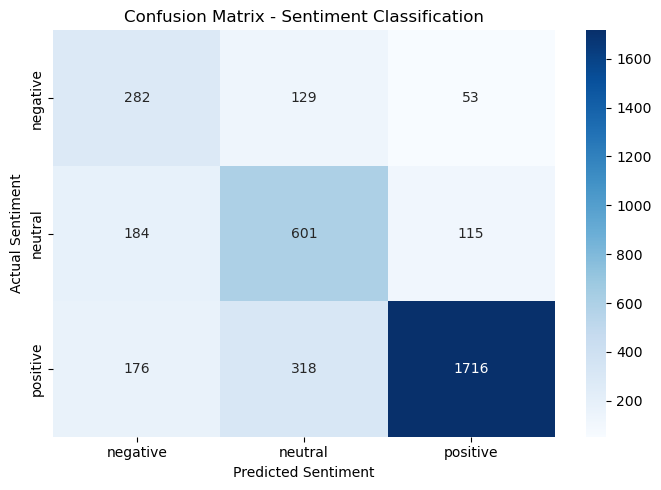

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels = [
    "negative",
    "neutral",
    "positive"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Sentiment Classification")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

**Observation:**  
The TF-IDF Logistic Regression model achieves an overall accuracy of 72.7%
and a weighted F1 Score of 0.74.

The model performs strongest on Positive comments, achieving an F1 Score of
0.84. Performance is moderate for Neutral comments and comparatively weaker
for Negative comments, partly due to the smaller number of Negative examples
available in the dataset.

Overall, the model demonstrates useful sentiment classification capability
across real user comments.

## Relatability Analysis

The sentiment model identifies whether a comment is Positive, Neutral, or Negative.
However, sentiment and relatability are different concepts.

Since the dataset does not contain manually labelled Relatable/Neutral classes,
a rule-based linguistic trigger approach is used to identify comments that
express personal identification, shared experience, or emotional recognition.

In [41]:
# Direct phrases that strongly indicate relatability
strong_relatable_patterns = [
    r"\bi can relate\b",
    r"\bso relatable\b",
    r"\bliterally me\b",
    r"\bthis is me\b",
    r"\bthat's me\b",
    r"\bme too\b",
    r"\bsame here\b",
    r"\bthis hits home\b",
    r"\bi needed this\b",
    r"\bthis describes me\b",
    r"\bi thought i was the only one\b",
    r"\bthought i was the only one\b",
    r"\bi'?m not the only one\b",
    r"\bnot alone\b",
    r"\bthis happened to me\b",
    r"\bi'?ve been through this\b",
    r"\bi have been through this\b"
]

# Stronger shared-experience combinations
shared_experience_patterns = [
    r"\bi (also )?(feel|felt|struggle|struggled|deal|dealt).{0,40}\b(this|that|too|same)\b",
    r"\bi (also )?(went through|have been through|experienced).{0,40}\b(this|that|same)\b",
    r"\b(this|that).{0,40}\b(happened to me|describes me|reminds me of myself)\b",
    r"\bwhat (you|he|she|they) said.{0,40}\b(i can relate|happened to me|is so relatable)\b"
]

In [42]:
def detect_relatability(text):
    text = str(text).lower()

    for pattern in strong_relatable_patterns:
        if re.search(pattern, text):
            return "Relatable"

    for pattern in shared_experience_patterns:
        if re.search(pattern, text):
            return "Relatable"

    return "Neutral"

In [43]:
comments_df["Relatability"] = (
    comments_df["Clean_Comment"]
    .apply(detect_relatability)
)

comments_df["Relatability"].value_counts()

Relatability
Neutral      17752
Relatable      116
Name: count, dtype: int64

In [44]:
comments_df[
    comments_df["Relatability"] == "Relatable"
][
    ["Comment", "Sentiment", "Relatability"]
].head(20)

,Comment,Sentiment,Relatability
47,personally i feel like this is really out of touch most students wont be able to afford these in case anyone needs it i believe dave2ds back to sc...,positive,Relatable
154,as someone who used to work 80 hours a week quitting my job to become a freelancer was the best thing i have ever done sure i still work a lot of ...,positive,Relatable
280,for all people after covid who want their smell back i did exactly what she described but went a step further and tried to smell back first smells...,positive,Relatable
493,i feel for civilians that just want to live a peaceful normal life in ukraine,negative,Relatable
525,i feel like i’m in a simulation at this point,negative,Relatable
682,i feel so bad for the victim of that bombing my heart goes out to the car,negative,Relatable
1111,the r3 l3 one is so relatable i had a transformers game on the wiiu a while back and it took me months to figure it out,positive,Relatable
1282,all her music is just so good like i can relate to most of it and the sounds in her music are so sad yet upbeat and happy ive never heard music li...,positive,Relatable
1283,this song is my go to whenever i feel something this song usually helps me go back to feeling empty thanks,positive,Relatable
1360,i feel like most people watching this video have 0 idea how unbelievable it is that they were allowed to even be at augusta before the masters let...,negative,Relatable


## Final NLP Analysis Summary

The NLP module combines two complementary analyses:

1. A TF-IDF Logistic Regression model classifies comments as Positive,
   Neutral, or Negative.
2. A rule-based linguistic trigger system identifies comments showing
   strong signs of personal relatability.

Sentiment and relatability are treated as separate concepts.

In [45]:
print("Sentiment Distribution:")
print(comments_df["Sentiment"].value_counts())

print("\nRelatability Distribution:")
print(comments_df["Relatability"].value_counts())

relatable_percentage = (
    (comments_df["Relatability"] == "Relatable").mean() * 100
)

print(
    "\nRelatable Comments (%):",
    round(relatable_percentage, 2)
)

Sentiment Distribution:
Sentiment
positive    11051
neutral      4500
negative     2317
Name: count, dtype: int64

Relatability Distribution:
Relatability
Neutral      17752
Relatable      116
Name: count, dtype: int64

Relatable Comments (%): 0.65


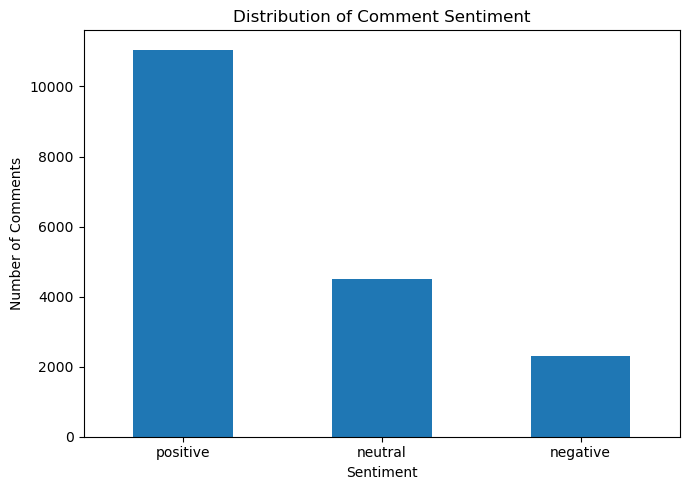

In [46]:
sentiment_counts = comments_df["Sentiment"].value_counts()

sentiment_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Comment Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**  
Positive comments form the largest sentiment group, followed by Neutral and
Negative comments. The sentiment dataset is therefore imbalanced, which was
addressed during model training using balanced class weights.

## Comment Analysis Function

The final function combines the trained sentiment classifier and the
relatability detector to analyze new user comments.

In [47]:
def analyze_comment(comment):

    # Clean the new comment
    cleaned = clean_text(comment)

    # Convert text using trained TF-IDF vectorizer
    vectorized = tfidf.transform([cleaned])

    # Predict sentiment
    predicted_sentiment = sentiment_model.predict(
        vectorized
    )[0]

    # Detect relatability
    relatability = detect_relatability(cleaned)

    return {
        "Comment": comment,
        "Predicted_Sentiment": predicted_sentiment,
        "Relatability": relatability
    }

In [48]:
analyze_comment(
    "I can relate to this so much, I thought I was the only one."
)

{'Comment': 'I can relate to this so much, I thought I was the only one.',
 'Predicted_Sentiment': 'positive',
 'Relatability': 'Relatable'}

In [49]:
analyze_comment(
    "This video explains the topic clearly."
)

{'Comment': 'This video explains the topic clearly.',
 'Predicted_Sentiment': 'neutral',
 'Relatability': 'Neutral'}

In [50]:
comments_df.to_csv(
    "cleaned_youtube_comments_nlp.csv",
    index=False
)

print("Cleaned NLP dataset saved successfully.")

Cleaned NLP dataset saved successfully.


In [53]:
import joblib

joblib.dump(
    sentiment_model,
    "sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("Sentiment model and TF-IDF vectorizer saved successfully.")

Sentiment model and TF-IDF vectorizer saved successfully.
